In [1]:
import pandas as pd
import os

In [2]:
file_path = 'BASE DE DADOS PEDE 2024 - DATATHON - NORMALIZADA.txt'
df = pd.read_csv(file_path, sep=';') # Correcting to semicolon-separated values
display(df.head())

,RA,Fase,Turma,Nome,Data de Nasc,Ano Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Origem
0,RA-1,7,A,ALUNO-1,NaN,2003,19.0,MENINA,2016,ESCOLA PÚBLICA,...,7.278,5.0,FASE 8 (UNIVERSITÁRIOS),-1,MELHORAR: MELHORAR A SUA ENTREGA DE LIÇÕES DE ...,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,MELHORAR: INTEGRAR-SE MAIS AOS PRINCÍPIOS PASS...,NaN,NaN,PEDE2022
1,RA-2,7,A,ALUNO-2,NaN,2005,17.0,MENINA,2017,REDE DECISÃO,...,6.778,10.0,FASE 7 (3º EM),0,MELHORAR: MELHORAR A SUA ENTREGA DE LIÇÕES DE ...,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,MELHORAR: INTEGRAR-SE MAIS AOS PRINCÍPIOS PASS...,NaN,NaN,PEDE2022
2,RA-3,7,A,ALUNO-3,NaN,2005,17.0,MENINA,2016,REDE DECISÃO,...,7.556,10.0,FASE 7 (3º EM),0,DESTAQUE: A SUA BOA ENTREGA DAS LIÇÕES DE CASA.,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,DESTAQUE: A SUA BOA INTEGRAÇÃO AOS PRINCÍPIOS ...,NaN,NaN,PEDE2022
3,RA-4,7,A,ALUNO-4,NaN,2005,17.0,MENINO,2017,REDE DECISÃO,...,5.278,10.0,FASE 7 (3º EM),0,MELHORAR: MELHORAR A SUA ENTREGA DE LIÇÕES DE ...,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,MELHORAR: INTEGRAR-SE MAIS AOS PRINCÍPIOS PASS...,NaN,NaN,PEDE2022
4,RA-5,7,A,ALUNO-5,NaN,2005,17.0,MENINA,2016,REDE DECISÃO,...,7.389,10.0,FASE 7 (3º EM),0,DESTAQUE: A SUA BOA ENTREGA DAS LIÇÕES DE CASA.,MELHORAR: EMPENHAR-SE MAIS NAS AULAS E AVALIAÇ...,MELHORAR: INTEGRAR-SE MAIS AOS PRINCÍPIOS PASS...,NaN,NaN,PEDE2022


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 53 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   str    
 1   Fase                   3030 non-null   str    
 2   Turma                  3030 non-null   str    
 3   Nome                   3030 non-null   str    
 4   Data de Nasc           2170 non-null   str    
 5   Ano Nasc               3030 non-null   int64  
 6   Idade                  2631 non-null   float64
 7   Gênero                 3030 non-null   str    
 8   Ano ingresso           3030 non-null   int64  
 9   Instituição de ensino  3029 non-null   str    
 10  Pedra 20               754 non-null    str    
 11  Pedra 21               1061 non-null   str    
 12  Pedra 22               1932 non-null   str    
 13  INDE 22                1932 non-null   float64
 14  Pedra 23               1621 non-null   str    
 15  INDE 23        

In [4]:
display(df['Defasagem'])

0      -1
1       0
2       0
3       0
4       0
       ..
3025    1
3026    1
3027    1
3028    1
3029    1
Name: Defasagem, Length: 3030, dtype: int64

In [5]:
display(df['Defasagem'].value_counts())

Defasagem
-1    1259
 0    1152
-2     383
 1     165
-3      39
 2      24
-4       5
 3       2
-5       1
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

# Dividir a base de treino (80) e teste (20)

In [7]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Shape of training set: {train_df.shape}")
print(f"Shape of testing set: {test_df.shape}")

Shape of training set: (2424, 53)
Shape of testing set: (606, 53)


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definir a variável alvo
# Assumindo que 'defasagem' significa Defasagem < 0
# 0 se não defasagem e 1 se for defasagem
train_df['target'] = (train_df['Defasagem'] < 0).astype(int)
test_df['target'] = (test_df['Defasagem'] < 0).astype(int)

print(f"Distribuição do alvo no conjunto de treino:\n{train_df['target'].value_counts()}")
print(f"Distribuição do alvo no conjunto de teste:\n{test_df['target'].value_counts()}")

# Identificar as colunas a serem excluídas (apenas o alvo e sua origem para evitar vazamento de dados)
exclude_cols = ['Defasagem', 'target']

# Separar features (X) e alvo (y)
X_train = train_df.drop(columns=exclude_cols, errors='ignore')
y_train = train_df['target']

X_test = test_df.drop(columns=exclude_cols, errors='ignore')
y_test = test_df['target']

# Identificar colunas numéricas e categóricas
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

print(f"\nColunas numéricas: {list(numerical_cols)}")
print(f"Colunas categóricas: {list(categorical_cols)}")

# Criar pipelines de pré-processamento para features numéricas e categóricas
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Normalizar/padronizar as variaveis strings
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Criar um objeto preprocessor usando ColumnTransformer
# Transformar as variaveis numericas em num
# Transformar as variaveis strings em cat
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Manter outras colunas (se houver, embora nenhuma seja esperada aqui após a seleção inicial)
)

# Aplicar pré-processamento aos dados de treino e teste
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"\nTamanho dos dados de treino pré-processados: {X_train_preprocessed.shape}")
print(f"Tamanho dos dados de teste pré-processados: {X_test_preprocessed.shape}")

Distribuição do alvo no conjunto de treino:
target
1    1347
0    1077
Name: count, dtype: int64
Distribuição do alvo no conjunto de teste:
target
1    340
0    266
Name: count, dtype: int64

Colunas numéricas: ['Ano Nasc', 'Idade', 'Ano ingresso', 'INDE 22', 'INDE 23', 'INDE 24', 'Cg', 'Cf', 'Ct', 'Nº Av', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'Mat', 'Por', 'Ing', 'IPV', 'IAN']
Colunas categóricas: ['RA', 'Fase', 'Turma', 'Nome', 'Data de Nasc', 'Gênero', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'Pedra 24', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'Avaliador5', 'Avaliador6', 'Rec Psicologia', 'Indicado', 'Atingiu PV', 'Fase Ideal', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Escola', 'Ativo/ Inativo', 'Origem']


C:\Users\Evandro\AppData\Local\Temp\ipykernel_34832\3962555830.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns



Tamanho dos dados de treino pré-processados: (2424, 4666)
Tamanho dos dados de teste pré-processados: (606, 4666)


In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_shape = X_train_preprocessed.shape[1]

# Rede neural em 3 camadas
# Primeiro camada tem 128 neuronios
# Segunda camada tem 64 neuronios
# Terceita camada tem 1 neuronio, com função de probabilidade 0-1
model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Saída para classificação binária (probabilidade)
])

# accuracy com metrica para o treinamento, quanto melhor a acuraria melhor é a precisão da rede neural
# optimizer = adam, tenta convergir para o minimo
# binary_crossentropy, forçar dar valor 0 ou 1. Basicamente avalia diferença entre as probabilidades
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       597,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,697 (2.31 MB)

 Trainable params: 605,697 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Treinar o modelo
history = model.fit(
    X_train_preprocessed, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8442 - loss: 0.3796 - val_accuracy: 0.9938 - val_loss: 0.0543
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9974 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 6.0702e-04 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 5.4410e-04 - val_accuracy: 1.0000 - val_loss: 7.4931e-04
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 3.7547e-04 - val_accu

In [11]:
# Avaliar o modelo no conjunto de teste
loss, accuracy = model.evaluate(X_test_preprocessed, y_test, verbose=0)
print(f"\nPerda no conjunto de teste: {loss:.4f}")
print(f"Acurácia no conjunto de teste: {accuracy:.4f}")

# Fazer previsões (probabilidades) no conjunto de teste
y_pred_proba = model.predict(X_test_preprocessed)

print("\nAlgumas previsões de probabilidade (primeiras 10):")
for i in range(10):
    print(f"Real: {y_test.iloc[i]}, Probabilidade Prevista: {y_pred_proba[i][0]:.4f}")



Perda no conjunto de teste: 0.0002
Acurácia no conjunto de teste: 1.0000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Algumas previsões de probabilidade (primeiras 10):
Real: 1, Probabilidade Prevista: 0.9997
Real: 1, Probabilidade Prevista: 1.0000
Real: 1, Probabilidade Prevista: 1.0000
Real: 0, Probabilidade Prevista: 0.0000
Real: 1, Probabilidade Prevista: 0.9999
Real: 1, Probabilidade Prevista: 1.0000
Real: 1, Probabilidade Prevista: 1.0000
Real: 1, Probabilidade Prevista: 1.0000
Real: 1, Probabilidade Prevista: 1.0000
Real: 0, Probabilidade Prevista: 0.0013


In [12]:
import numpy as np

distinct_probabilities = np.unique(y_pred_proba)

print("Valores de probabilidade distintos (truncados em 2 casas decimais e em porcentagem):")
for prob in distinct_probabilities:
    print(f"{prob:.2%}")
print(f"Total de valores distintos: {len(distinct_probabilities)}")

Valores de probabilidade distintos (truncados em 2 casas decimais e em porcentagem):
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.00%
0.0

In [13]:
model_save_path = 'modelo_keras_final.keras'

# Isso salvará a arquitetura do modelo, os pesos e a configuração de compilação.
if os.path.exists(model_save_path):
    os.remove(model_save_path)
    print(f"\nArquivo '{model_save_path}' existente removido.")

model.save(model_save_path)

print(f"Modelo salvo com sucesso em: {model_save_path}/")

# Vocês podem carregar o modelo posteriormente usando:
# loaded_model = tf.keras.models.load_model(model_save_path)


Arquivo 'modelo_keras_final.keras' existente removido.
Modelo salvo com sucesso em: modelo_keras_final.keras/


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

threshold = 0.5

y_pred_binary = (y_pred_proba > threshold).astype(int)

print(f"\nPrevisões binárias com limiar de {threshold}:")
print(y_pred_binary[:10].flatten())


print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_binary))

print("\nMatriz de Confusão:")
conf_matrix = confusion_matrix(y_test, y_pred_binary)
display(pd.DataFrame(conf_matrix, index=['Real 0', 'Real 1'], columns=['Previsto 0', 'Previsto 1']))

acc = accuracy_score(y_test, y_pred_binary)
print(f"\nAcurácia (com previsões binárias): {acc:.4f}")


Previsões binárias com limiar de 0.5:
[1 1 1 0 1 1 1 1 1 0]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       266
           1       1.00      1.00      1.00       340

    accuracy                           1.00       606
   macro avg       1.00      1.00      1.00       606
weighted avg       1.00      1.00      1.00       606


Matriz de Confusão:


,Previsto 0,Previsto 1
Real 0,266,0
Real 1,0,340



Acurácia (com previsões binárias): 1.0000


In [15]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

input_shape = X_train_preprocessed.shape[1]

# Função para criar o modelo
def create_model():
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

keras_model = KerasClassifier(
    model=create_model,
    epochs=20,
    batch_size=32,
    verbose=0
)

# Validação cruzada estratificada
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation
cv_scores = cross_val_score(
    keras_model,
    X_train_preprocessed,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

print(f"\nResultados da Validação Cruzada (Acurácia por fold): {cv_scores}")
print(f"Acurácia Média: {np.mean(cv_scores):.4f}")
print(f"Desvio Padrão: {np.std(cv_scores):.4f}")


Resultados da Validação Cruzada (Acurácia por fold): [1. 1. 1. 1. 1.]
Acurácia Média: 1.0000
Desvio Padrão: 0.0000


C:\Users\Evandro\AppData\Local\Temp\ipykernel_34832\2186051465.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(len(cv_scores))), y=cv_scores, palette='viridis')


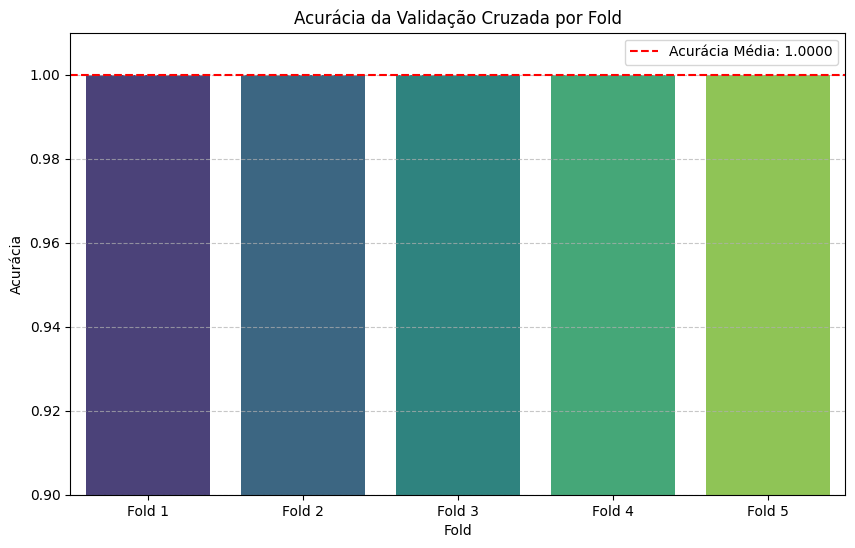

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=list(range(len(cv_scores))), y=cv_scores, palette='viridis')
plt.axhline(np.mean(cv_scores), color='r', linestyle='--', label=f'Acurácia Média: {np.mean(cv_scores):.4f}')
plt.title('Acurácia da Validação Cruzada por Fold')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.xticks(ticks=list(range(len(cv_scores))), labels=[f'Fold {i+1}' for i in range(len(cv_scores))])
plt.ylim(0.9, 1.01)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()